## Evaluation of Regression Models: Using the R² Score to measure model accuracy

## Importing libraries and the dataset

In [1]:
# Importing libraries
from IPython.display import display, HTML
import warnings

import pandas as pd
import plotly.express as px
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

display(HTML('<style>.container { width:90% !important; }</style>'))
warnings.filterwarnings("ignore")

In [2]:
# Importing data
df = pd.read_excel('hotels.xlsx')
df.head()

,Profit,Price in millions,Square meters,City
0,119000,21.88,3938,Berlin
1,250000,27.95,3986,München
2,250000,16.09,2574,Köln
3,145000,27.58,4155,München
4,110000,23.76,3795,Berlin


In [3]:
# Missing values?
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Profit             150 non-null    int64  
 1   Price in millions  150 non-null    float64
 2   Square meters      150 non-null    int64  
 3   City               150 non-null    object 
dtypes: float64(1), int64(2), object(1)
memory usage: 4.8+ KB


In [4]:
# Statistical information
df.describe()

,Profit,Price in millions,Square meters
count,150.000000,150.000000,150.000000
mean,106126.666667,17.101933,2594.680000
std,76413.507421,6.531691,1434.491133
min,2000.000000,4.160000,82.000000
25%,45500.000000,12.890000,1499.000000
50%,88500.000000,17.085000,2578.500000
75%,137750.000000,21.760000,3628.000000
max,250000.000000,35.350000,5741.000000


## Visualizing data

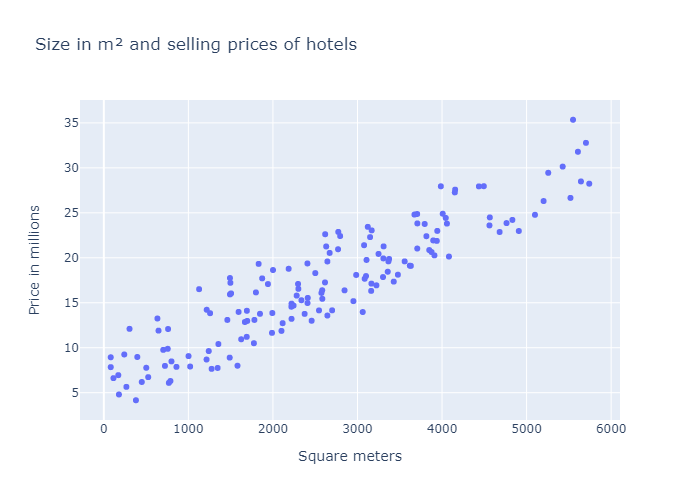

In [5]:
fig = px.scatter(df, x="Square meters", y="Price in millions", title="Size in m² and selling prices of hotels")
fig.show("png")

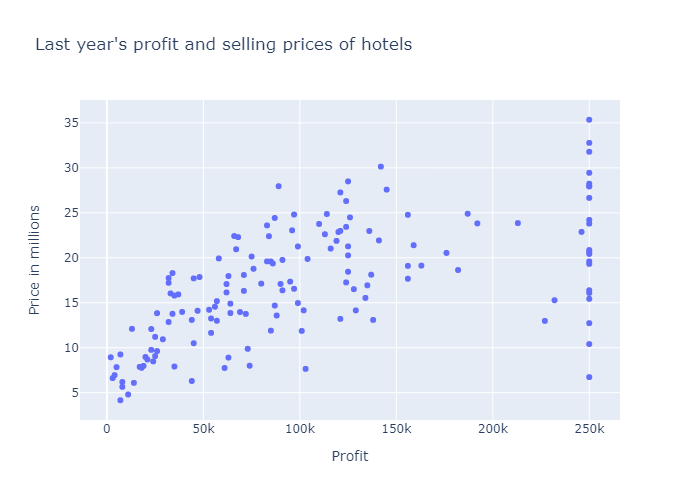

In [6]:
fig = px.scatter(df, x="Profit", y="Price in millions", title="Last year's profit and selling prices of hotels")
fig.show("png")

# The R² score or coefficient of determination:

### The coefficient of determination R² is a statistical measure that evaluates how well a regression model fits the observed data. It indicates the proportion of the variance in the dependent variable that is predictable from the independent variables.

### Interpretation of the R² score:

### R² = 0 = The model explains none of the variability of the response data around its mean. It suggests that the independent variables do not contribute to explaining the variation in the dependent variable.

### R² = 1 = The model perfectly predicts the dependent variable. All variability in the dependent variable is explained by the independent variables.

### Generally, an R² score above 0.7 or 0.8 is considered good, depending on the context and domain.

### In the following code cells, three different Linear Regression models with different input variables will be trained:
### Model 1: All input variables | Model 2: Using the size | Model 3: Using the profit

## Model 1: All input variables

In [7]:
# Generating an empty list
scores_all_variables = []

for i in range(0, 100):

    # Defining features
    X = df[['Square meters', 'Profit']]
    y = df[['Price in millions']]

    # Performing the train test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25)

    # Instantiate model
    model = LinearRegression()

    # Train model
    model.fit(X_train, y_train)

    # Generating predictions
    y_pred = model.predict(X_test)

    # Output R² score
    r2 = r2_score(y_test, y_pred)
    scores_all_variables.append(r2)

print('Using all input variables, the average R² score of 100 Linear Regression trainings is:', sum(scores_all_variables) / len(scores_all_variables))

Using all input variables, the average R² score of 100 Linear Regression trainings is: 0.8219718090568403


## Model 2: Using the size

In [8]:
# Generating an empty list
scores_square_meters = []

for i in range(0, 100):

    # Defining features
    X = df[['Square meters']]
    y = df[['Price in millions']]

    # Performing the train test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25)

    # Instantiate model
    model = LinearRegression()

    # Train model
    model.fit(X_train, y_train)

    # Generating predictions
    y_pred = model.predict(X_test)

    # Output R² score
    r2 = r2_score(y_test, y_pred)
    scores_square_meters.append(r2)

print('Using the size as the input variable, the average R² score of 100 Linear Regression trainings is:', sum(scores_square_meters) / len(scores_square_meters))

Using the size as the input variable, the average R² score of 100 Linear Regression trainings is: 0.8228399163863096


## Model 3: Using the profit

In [9]:
# Generating an empty list
scores_profit = []

for i in range(0, 100):

    # Defining features
    X = df[['Profit']]
    y = df[['Price in millions']]

    # Performing the train test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25)

    # Instantiate model
    model = LinearRegression()

    # Train model
    model.fit(X_train, y_train)

    # Generating predictions
    y_pred = model.predict(X_test)

    # Output R² score
    r2 = r2_score(y_test, y_pred)
    scores_profit.append(r2)

print('Using the profit as the input variable, the average R² score of 100 Linear Regression trainings is::', sum(scores_profit) / len(scores_profit))

Using the profit as the input variable, the average R² score of 100 Linear Regression trainings is:: 0.2911742035424713


## Comparing the models

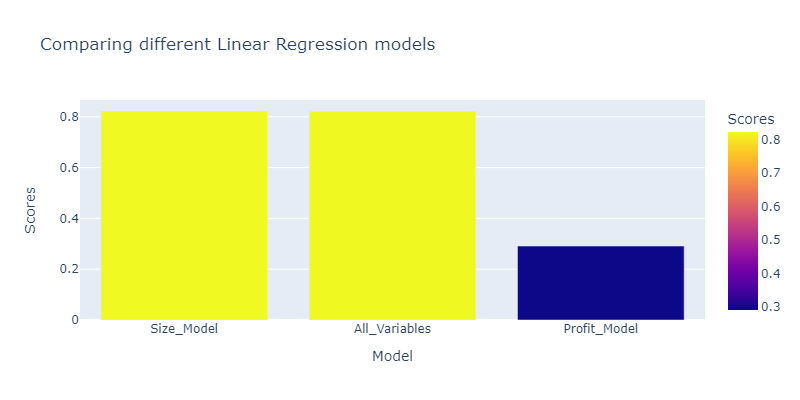

In [10]:
data = {'Scores': [sum(scores_all_variables) / len(scores_all_variables), sum(scores_square_meters) / len(scores_square_meters), sum(scores_profit) / len(scores_profit)],
        'Model': ['All_Variables', 'Size_Model', 'Profit_Model']
        }

score_viz = pd.DataFrame(data)
score_viz = score_viz.sort_values('Scores', ascending=False)

fig = px.bar(score_viz, x='Model', y='Scores', color='Scores', height=400, width=800, title='Comparing different Linear Regression models')
fig.show("png")

## Conclusion:

## Using just the size of hotels as the input variable is enough to generate a robust Linear Regression model which can predict the price of a hotel with great accuracy. 
## Using all input variables is not required. In fact, focusing on only one variable slightly increased the accuracy of the model.